In [1]:
import h5py
import xarray as xr
import imageio
import matplotlib.pyplot as plt
import os
import numpy as np
import tidy3d as td
import matplotlib
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from scipy.fft import fftn, ifftn, fftshift
from scipy.interpolate import interp1d
from scipy.signal import argrelextrema
import sys
import scipy
from scipy.ndimage import gaussian_filter1d
# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(rf'../../../../../tidy3d'))

from AutomationModule import * 

import AutomationModule as AM

tidy3dAPI = os.environ["API_TIDY3D_KEY"]
plt.rc('font', family='Arial')

In [2]:
data = AM.read_hdf5_as_dict("./data/L_1_12x/field_data_12x_raw_field_Ex_Ey_Ez_L_1_ff_0p2237_n_2p90.h5")

In [3]:
data.keys()

dict_keys(['2.90'])

In [4]:
gap_data = AM.read_hdf5_as_dict(rf"../../20250630 MPB Bands analysis/Data/gap_data.hdf5")
gaps_ff_22_n_2p90=14.3/(gap_data["Circular"]["0.22"]["gap_edges"][np.where(gap_data["Circular"]["0.22"]["n"]==2.9)[0]]).flatten()

In [5]:
a=2.562629142772549
gap_center = a/(np.sum(gaps_ff_22_n_2p90)/2)


In [6]:
def diameter(intensity_array,x,y):
    intensity = intensity_array
    integral_1 = scipy.integrate.simpson(scipy.integrate.simpson(intensity**2, x=y, axis=1), x=x, axis=0)
    integral_2 = scipy.integrate.simpson(scipy.integrate.simpson(intensity, x=y, axis=1), x=x, axis=0)**2
    
    return 2*np.sqrt((integral_2/integral_1)/np.pi)


def moving_average(x, w=3):
    if w <= 1:
        return x
    return np.convolve(x, np.ones(w), 'valid') / w

In [7]:
from scipy.fft import fft  # forward FFT inverts Tidy3D's exp(+2*pi*i*f*t) DFT convention
from scipy.signal.windows import gaussian, tukey

def diameter_time_domain(field, a, nu_center=None, delta_nu=0.3,
                         intensity_floor=1e-12, chunk=64, window="hann"):
    """Reconstruct the time-domain beam diameter ``d(t)`` from the
    frequency-domain field.

    A window of normalized width ``delta_nu`` (in units of ``a/lambda = a*f/c``)
    is selected from the spectrum and Fourier transformed back to the time
    domain.  The uniform frequency spacing ``df`` of the stored band sets the
    time window  ``T = 1/df`` (~20 ps here, the original simulation duration),
    while the window bandwidth  ``delta_f = delta_nu * c / a``  sets the time
    resolution  ``dt = 1/delta_f``.

    Tidy3D stores the spectrum with the ``exp(+2*pi*i*f*t)`` convention, so the
    forward ``fft`` is the correct inverse and produces a forward-running time
    axis ``t`` in ``[0, T)``. The (carrier) phase from the non-zero start
    frequency cancels in ``|E(t)|**2``, which is the intensity envelope.

    Parameters
    ----------
    field : dict with complex 'Ex','Ey','Ez' of shape (nx, ny, 1, nf) and the
            coordinate arrays 'x', 'y', 'f' (Hz).
    a : lattice constant (length unit) used for the normalization.
    nu_center : center of the frequency window in normalized units (a*f/c).
                Defaults to the lowest delta_nu-wide window.
    delta_nu : width of the frequency window in normalized units (default 0.3).

    Returns
    -------
    t : time axis in seconds, shape (Nwin,)
    d_t : diameter(t) / a (dimensionless), shape (Nwin,)
    nu_center : the window center actually used.
    """
    x, y = np.asarray(field["x"]), np.asarray(field["y"])
    f = np.asarray(field["f"])
    nu = a * f / td.C_0                       # normalized frequency a*f/c
    df = np.mean(np.diff(f))                  # uniform spacing of the full band

    if nu_center is None:
        nu_center = nu.min() + delta_nu / 2   # lowest delta_nu-wide window

    # frequencies inside the window
    idx = np.where((nu >= nu_center - delta_nu / 2) &
                   (nu <= nu_center + delta_nu / 2))[0]
    Nwin = idx.size
    print(f"Window: nu_center={nu_center:.3f}, delta_nu={delta_nu}, Nwin={Nwin}")
    # Smooth frequency window — kills sinc overshoot
    if window == "box":
        w = np.ones(Nwin)
    elif window == "hann":
        w = np.hanning(Nwin)
    elif window == "tukey":
        w = tukey(Nwin, alpha=0.5)
    elif window == "gauss":
        w = gaussian(Nwin, std=Nwin / 6)   # ~3σ inside the window
    else:
        raise ValueError(window)
    w = w.astype(np.complex64)

    # time axis: dt = 1/bandwidth, T = Nwin*dt = 1/df  (~ simulation time)
    dt = 1.0 / (Nwin * df)
    t = np.arange(Nwin) * dt
    print(f"Time axis: dt={dt*1e12:.2f} fs, T={t[-1]*1e12:.2f} ps")
    # |E(t)|^2 envelope summed over components; FFT in x-chunks to limit RAM
    nx, ny = x.size, y.size
    intensity_t = np.zeros((nx, ny, Nwin), dtype=np.float32)
    for comp in ("Ex", "Ey", "Ez"):
        comp_arr = field[comp]
        for i0 in range(0, nx, chunk):
            i1 = min(i0 + chunk, nx)
            E_w = np.asarray(comp_arr[i0:i1, :, 0, idx])  # freq-domain slice
            E_t = fft(E_w, axis=-1)                        # -> time domain
            intensity_t[i0:i1] += (E_t.real ** 2 + E_t.imag ** 2).astype(np.float32)
            del E_w, E_t

    # diameter at every time step (diameter is scale invariant; floor removes noise)
    d_t = np.empty(Nwin)
    for m in range(Nwin):
        I_peak = intensity_t.max()
        I = intensity_t[..., m].astype(np.float64) / I_peak
        I[I <= intensity_floor] = 0.0
        d_t[m] = diameter(I, x, y)

    P_t = intensity_t.sum(axis=(0, 1))
    t_d = t[np.argmax(P_t)]

    return t, d_t / a, nu_center,t_d


Window: nu_center=0.330, delta_nu=0.03, Nwin=60
Time axis: dt=0.34 fs, T=20.26 ps
Window: nu_center=0.420, delta_nu=0.03, Nwin=72
Time axis: dt=0.29 fs, T=20.32 ps
Window: nu_center=0.446, delta_nu=0.03, Nwin=72
Time axis: dt=0.29 fs, T=20.32 ps
Window: nu_center=0.470, delta_nu=0.03, Nwin=73
Time axis: dt=0.28 fs, T=20.33 ps
Window: nu_center=0.580, delta_nu=0.03, Nwin=73
Time axis: dt=0.28 fs, T=20.33 ps


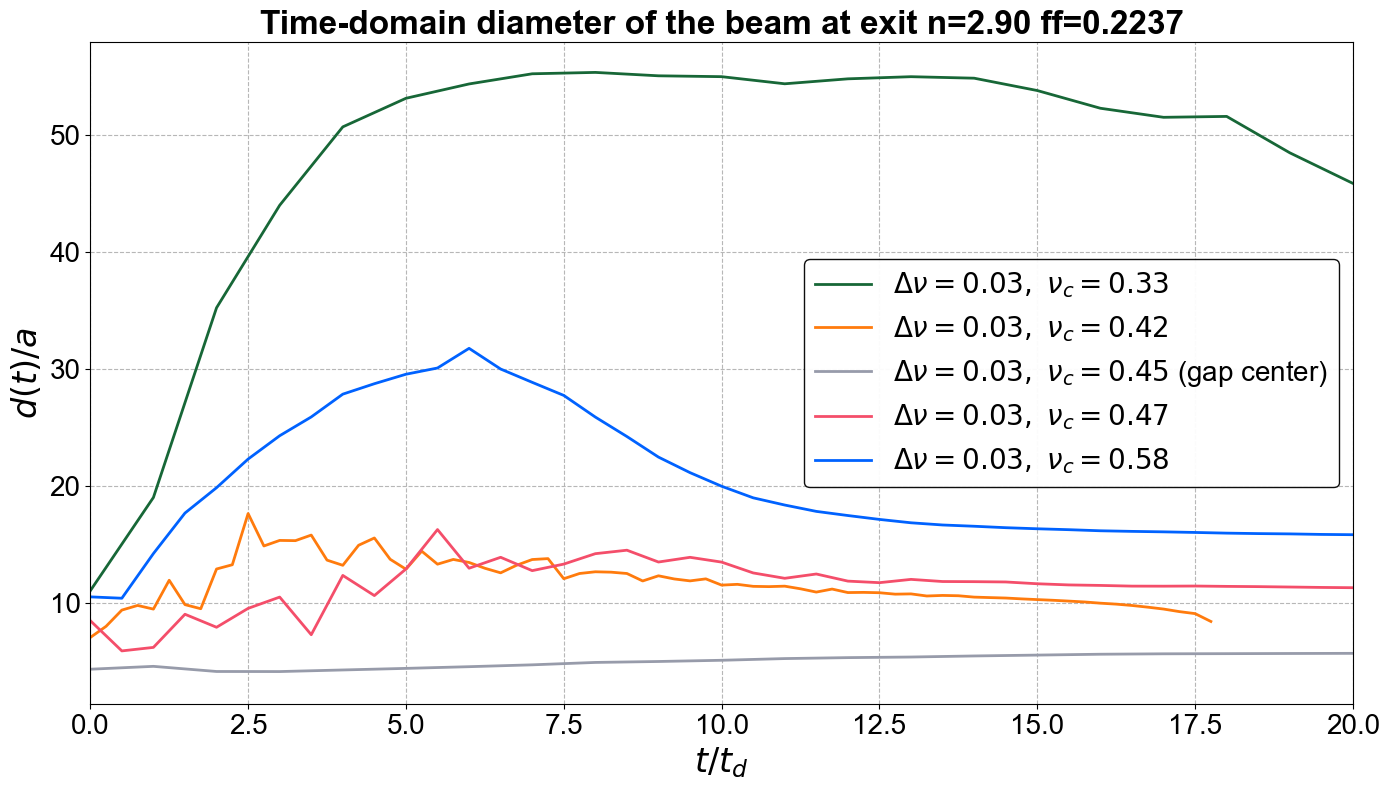

In [ ]:

# --- time-domain beam diameter for a delta_nu = 0.3 window over the 20 ps run ---
fig, ax = plt.subplots(figsize=(14, 8), dpi=100)
delta_nu = 0.03
for nu_center in [0.33,0.42, gap_center,0.47,0.58]:
    t, d_t, nu_c, t_d = diameter_time_domain(data["2.90"], a, nu_center=nu_center, delta_nu=delta_nu,window="gauss")
    ax.plot(t/t_d, d_t, lw=2,
            label=rf"$\Delta\nu={delta_nu},\ \nu_c={nu_c:.2f}$" + (rf" (gap center)" if np.isclose(nu_c, gap_center) else ""))

ax.set_xlabel(r"$t/t_d$", fontsize=24, fontweight='bold')
ax.set_ylabel(r"$d(t)/a$", fontsize=24, fontweight='bold')  
ax.grid(True, which="both", alpha=0.9, linestyle='--')
ax.legend(loc='best', fontsize=20, framealpha=0.95, edgecolor='black')
ax.set_xlim(0, 20)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_title(r"Time-domain diameter of the beam at exit n=2.90 ff=0.2237", fontsize=24, fontweight='bold')
ax
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()